# 04 Validation and Robustness

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import display

ARTIFACT_DIR = Path.cwd() / "notebook_artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)


In [2]:
# Clustering-Artefakte aus dem vorherigen Notebook laden

with open(ARTIFACT_DIR / "03_baseline_clustering_artifacts.pkl", "rb") as f:
    baseline_clustering_artifacts = pickle.load(f)

debitor_features_final = baseline_clustering_artifacts["debitor_features_final"]
baseline_feature_cols = baseline_clustering_artifacts["baseline_feature_cols"]
X_baseline_scaled = baseline_clustering_artifacts["X_baseline_scaled"]
k_selected = baseline_clustering_artifacts["k_selected"]
clustering_results_df = baseline_clustering_artifacts["clustering_results_df"]

print("Geladen:", ARTIFACT_DIR / "03_baseline_clustering_artifacts.pkl")
print("Debitoren:", debitor_features_final.shape[0])
print("Features:", debitor_features_final.shape[1])

Geladen: c:\Users\jensm\Documents\data01-executive-search-analytics\notebooks\notebook_artifacts\03_baseline_clustering_artifacts.pkl
Debitoren: 1361
Features: 28


In [3]:
# Validierungsmetriken für die Clusterqualität vorbereiten

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [4]:
# Clusterqualität für verschiedene Clusterzahlen berechnen

k_values = range(2, 9)

cluster_validation_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_baseline_scaled)

    silhouette = silhouette_score(X_baseline_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_baseline_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_baseline_scaled, labels)

    cluster_validation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

cluster_validation_df = pd.DataFrame(cluster_validation_results)
cluster_validation_df

NameError: name 'KMeans' is not defined

In [ ]:
# Validierungsergebnisse gerundet darstellen

cluster_validation_df_rounded = cluster_validation_df.copy()

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

cluster_validation_df_rounded[metric_cols] = cluster_validation_df_rounded[metric_cols].round(4)
cluster_validation_df_rounded

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,7954.8065,0.5850,0.8526,501.1071
1,3,6307.5635,0.2805,1.2667,493.0786
2,4,5176.9277,0.3101,1.1025,499.0041
3,5,4429.8410,0.2980,1.1345,494.2200
4,6,3890.9920,0.2614,1.1402,487.3280
5,7,3471.9456,0.2600,1.1210,482.0252
6,8,3112.7433,0.2685,1.0784,482.8044


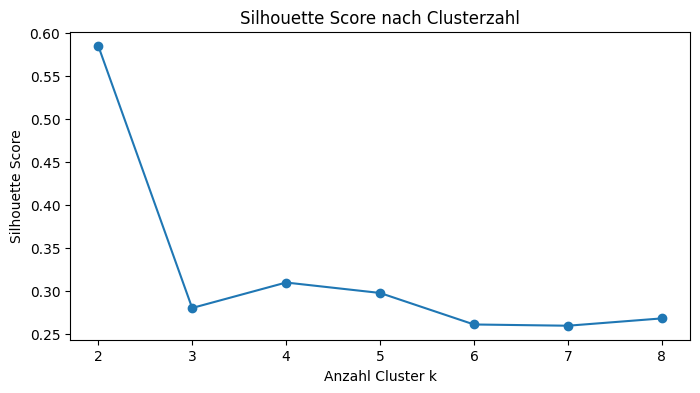

In [ ]:
# Silhouette Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["silhouette_score"], marker="o")
plt.title("Silhouette Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

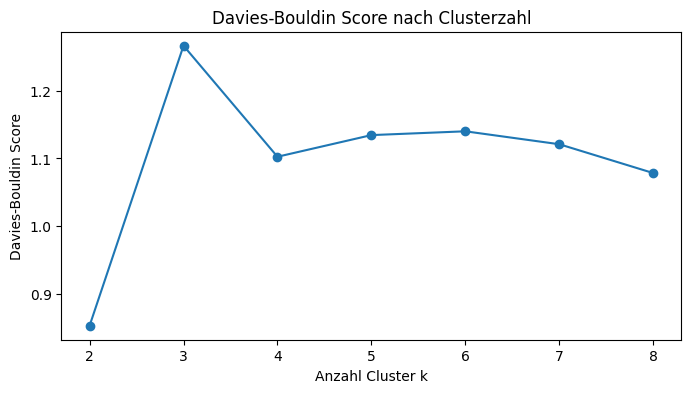

In [ ]:
# Davies-Bouldin Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values))
plt.show()

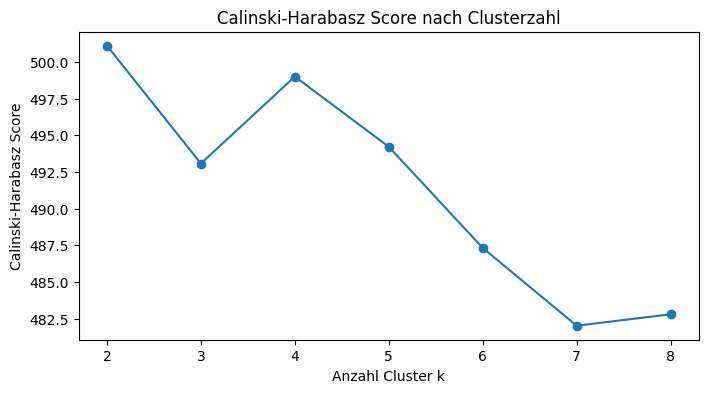

In [ ]:
# Calinski-Harabasz Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["calinski_harabasz_score"], marker="o")
plt.title("Calinski-Harabasz Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Beste Clusterzahl je Metrik identifizieren

best_silhouette_k = cluster_validation_df.loc[cluster_validation_df["silhouette_score"].idxmax(), "k"]
best_davies_bouldin_k = cluster_validation_df.loc[cluster_validation_df["davies_bouldin_score"].idxmin(), "k"]
best_calinski_harabasz_k = cluster_validation_df.loc[cluster_validation_df["calinski_harabasz_score"].idxmax(), "k"]

print(f"Bestes k nach Silhouette Score: {best_silhouette_k}")
print(f"Bestes k nach Davies-Bouldin Score: {best_davies_bouldin_k}")
print(f"Bestes k nach Calinski-Harabasz Score: {best_calinski_harabasz_k}")

Bestes k nach Silhouette Score: 2
Bestes k nach Davies-Bouldin Score: 2
Bestes k nach Calinski-Harabasz Score: 2


In [ ]:
# Aktuell gewählte Arbeits-Clusterzahl mit den Metriken abgleichen

selected_k_metrics = cluster_validation_df_rounded[cluster_validation_df_rounded["k"] == k_selected]
selected_k_metrics

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,7954.8065,0.585,0.8526,501.1071


In [ ]:
# Validierungsergebnisse als Arbeitsbasis festhalten

cluster_validation_results_df = cluster_validation_df.copy()

print("Validierungsergebnisse wurden als Arbeitsbasis gespeichert.")
print(cluster_validation_results_df.shape)

Validierungsergebnisse wurden als Arbeitsbasis gespeichert.
(7, 5)


## Methodische Notiz zur Clusterqualität

- Die Clusterqualität wurde für mehrere Clusterzahlen mit drei Standardmetriken geprüft.
- Berücksichtigt wurden Silhouette Score, Davies-Bouldin Score und Calinski-Harabasz Score.
- Die Metriken dienen als methodische Grundlage für die Wahl einer plausiblen Referenzlösung.
- Eine spätere Entscheidung kann zusätzlich fachliche Interpretierbarkeit und Business-Nutzen berücksichtigen.
- Aktuell wird die Zweierlösung als metrische Referenz priorisiert; eine Viererlösung bleibt explorativ prüfbar.

## Robustheitsprüfung der Segmentierung
Ziel der Robustheitsprüfung ist es zu prüfen, ob die identifizierte Clusterstruktur stabil bleibt, wenn die Merkmalsbasis in fachlich plausibler Weise variiert wird. Dazu werden mehrere alternative Feature-Sets definiert und mit K-Means über mehrere Clusterzahlen hinweg verglichen. Die Bewertung erfolgt anhand etablierter Clusterqualitätsmetriken, der Clustergrößen sowie der inhaltlichen Interpretierbarkeit der resultierenden Segmentprofile.

In [ ]:
# Alternative Feature-Sets für die Robustheitsprüfung definieren

robustness_feature_sets_raw = {
    "A_Referenzbaseline": [
        "invoice_count",
        "active_years_count",
        "recency_days",
        "net_index_sum",
        "net_per_invoice",
        "placement_count",
        "placement_rate",
        "leadership_rate"
    ],
    "B_Groessenreduziert": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "placement_rate",
        "leadership_rate"
    ],
    "C_Relational": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "invoices_per_active_year",
        "net_per_active_year",
        "placement_rate",
        "leadership_rate"
    ],
    "D_Struktur_erweitert": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "placement_rate",
        "leadership_rate",
        "contract_type_nunique",
        "revenue_subtype_nunique",
        "job_category_nunique",
        "industry_nunique"
    ]
}

robustness_feature_sets = {
    variant: [col for col in cols if col in debitor_features_final.columns]
    for variant, cols in robustness_feature_sets_raw.items()
}

print("Verfügbare Feature-Sets für die Robustheitsprüfung:")
for variant, cols in robustness_feature_sets.items():
    print()
    print(f"{variant}:")
    print(cols)

Verfügbare Feature-Sets für die Robustheitsprüfung:

A_Referenzbaseline:
['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

B_Groessenreduziert:
['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate']

C_Relational:
['active_years_count', 'recency_days', 'net_per_invoice', 'invoices_per_active_year', 'net_per_active_year', 'placement_rate', 'leadership_rate']

D_Struktur_erweitert:
['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']


In [ ]:
# Überblick über enthaltene und fehlende Features je Variante

robustness_feature_set_overview = []

for variant, planned_cols in robustness_feature_sets_raw.items():
    available_cols = robustness_feature_sets[variant]
    missing_cols = [col for col in planned_cols if col not in available_cols]

    robustness_feature_set_overview.append({
        "variante": variant,
        "geplante_features": len(planned_cols),
        "verfuegbare_features": len(available_cols),
        "fehlende_features": ", ".join(missing_cols) if missing_cols else "-"
    })

robustness_feature_set_overview_df = pd.DataFrame(robustness_feature_set_overview)
robustness_feature_set_overview_df

,variante,geplante_features,verfuegbare_features,fehlende_features
0,A_Referenzbaseline,8,8,-
1,B_Groessenreduziert,5,5,-
2,C_Relational,7,7,-
3,D_Struktur_erweitert,9,9,-


In [ ]:
# Vorbereitung für die Robustheitsprüfung

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_values_robustness = range(2, 7)

robustness_validation_results = []
robustness_prepared_data = {}

base_robustness_df = debitor_features_final.copy()

print("Ausgangsbasis der Robustheitsprüfung:")
print(f"Debitoren: {base_robustness_df.shape[0]}")
print(f"Verfügbare Spalten: {base_robustness_df.shape[1]}")

Ausgangsbasis der Robustheitsprüfung:
Debitoren: 1361
Verfügbare Spalten: 28


In [ ]:
# Alle Varianten über mehrere Clusterzahlen hinweg berechnen

for variant_name, feature_cols in robustness_feature_sets.items():
    if len(feature_cols) < 2:
        print(f"Variante {variant_name} wird übersprungen, da weniger als 2 Features verfügbar sind.")
        continue

    X_variant_raw = base_robustness_df[feature_cols].copy()

    imputer = SimpleImputer(strategy="median")
    X_variant_imputed = pd.DataFrame(
        imputer.fit_transform(X_variant_raw),
        columns=feature_cols,
        index=X_variant_raw.index
    )

    scaler = StandardScaler()
    X_variant_scaled = pd.DataFrame(
        scaler.fit_transform(X_variant_imputed),
        columns=feature_cols,
        index=X_variant_imputed.index
    )

    robustness_prepared_data[variant_name] = {
        "feature_cols": feature_cols,
        "X_raw": X_variant_raw,
        "X_imputed": X_variant_imputed,
        "X_scaled": X_variant_scaled
    }

    for k in k_values_robustness:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_variant_scaled)

        robustness_validation_results.append({
            "variante": variant_name,
            "k": k,
            "n_features": len(feature_cols),
            "features": ", ".join(feature_cols),
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette_score(X_variant_scaled, labels),
            "davies_bouldin_score": davies_bouldin_score(X_variant_scaled, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_variant_scaled, labels)
        })

print("Robustheitsläufe abgeschlossen.")
print(f"Anzahl Ergebniszeilen: {len(robustness_validation_results)}")

Robustheitsläufe abgeschlossen.
Anzahl Ergebniszeilen: 20


In [ ]:
# Validierungsergebnisse der Robustheitsprüfung als DataFrame aufbereiten

robustness_validation_df = pd.DataFrame(robustness_validation_results)

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

robustness_validation_df_rounded = robustness_validation_df.copy()
robustness_validation_df_rounded[metric_cols] = robustness_validation_df_rounded[metric_cols].round(4)

robustness_validation_df_rounded.sort_values(["variante", "k"]).reset_index(drop=True)

,variante,k,n_features,features,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,A_Referenzbaseline,2,8,"invoice_count, active_years_count, recency_day...",7954.8065,0.5850,0.8526,501.1071
1,A_Referenzbaseline,3,8,"invoice_count, active_years_count, recency_day...",6307.5635,0.2805,1.2667,493.0786
2,A_Referenzbaseline,4,8,"invoice_count, active_years_count, recency_day...",5176.9277,0.3101,1.1025,499.0041
3,A_Referenzbaseline,5,8,"invoice_count, active_years_count, recency_day...",4429.8410,0.2980,1.1345,494.2200
4,A_Referenzbaseline,6,8,"invoice_count, active_years_count, recency_day...",3890.9920,0.2614,1.1402,487.3280
5,B_Groessenreduziert,2,5,"active_years_count, recency_days, net_per_invo...",5158.3603,0.2907,1.4020,433.8168
6,B_Groessenreduziert,3,5,"active_years_count, recency_days, net_per_invo...",4157.5004,0.2999,1.2185,432.3878
7,B_Groessenreduziert,4,5,"active_years_count, recency_days, net_per_invo...",3414.1623,0.3060,1.1956,449.2431
8,B_Groessenreduziert,5,5,"active_years_count, recency_days, net_per_invo...",2882.7018,0.2778,1.1861,461.2545
9,B_Groessenreduziert,6,5,"active_years_count, recency_days, net_per_invo...",2532.7522,0.2852,1.1087,457.1230


In [ ]:
# Beste Clusterzahl je Variante identifizieren

best_rows_per_variant = []

for variant_name in robustness_validation_df["variante"].unique():
    variant_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name].copy()

    best_silhouette_row = variant_df.loc[variant_df["silhouette_score"].idxmax()]
    best_db_row = variant_df.loc[variant_df["davies_bouldin_score"].idxmin()]
    best_ch_row = variant_df.loc[variant_df["calinski_harabasz_score"].idxmax()]

    best_rows_per_variant.append({
        "variante": variant_name,
        "bestes_k_silhouette": int(best_silhouette_row["k"]),
        "bestes_k_davies_bouldin": int(best_db_row["k"]),
        "bestes_k_calinski_harabasz": int(best_ch_row["k"]),
        "max_silhouette_score": round(best_silhouette_row["silhouette_score"], 4),
        "min_davies_bouldin_score": round(best_db_row["davies_bouldin_score"], 4),
        "max_calinski_harabasz_score": round(best_ch_row["calinski_harabasz_score"], 4)
    })

robustness_best_k_df = pd.DataFrame(best_rows_per_variant)
robustness_best_k_df

,variante,bestes_k_silhouette,bestes_k_davies_bouldin,bestes_k_calinski_harabasz,max_silhouette_score,min_davies_bouldin_score,max_calinski_harabasz_score
0,A_Referenzbaseline,2,2,2,0.5850,0.8526,501.1071
1,B_Groessenreduziert,4,6,5,0.3060,1.1087,461.2545
2,C_Relational,3,5,3,0.2705,1.3105,370.4531
3,D_Struktur_erweitert,2,2,2,0.3229,1.4251,441.3816


In [ ]:
# Referenzvergleich für k = 2 und k = 4 erzeugen

robustness_reference_comparison_df = robustness_validation_df_rounded[
    robustness_validation_df_rounded["k"].isin([2, 4])
].sort_values(["k", "variante"]).reset_index(drop=True)

robustness_reference_comparison_df

,variante,k,n_features,features,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,A_Referenzbaseline,2,8,"invoice_count, active_years_count, recency_day...",7954.8065,0.5850,0.8526,501.1071
1,B_Groessenreduziert,2,5,"active_years_count, recency_days, net_per_invo...",5158.3603,0.2907,1.4020,433.8168
2,C_Relational,2,7,"active_years_count, recency_days, net_per_invo...",7576.5793,0.2252,1.7479,349.8441
3,D_Struktur_erweitert,2,9,"active_years_count, recency_days, net_per_invo...",9246.0351,0.3229,1.4251,441.3816
4,A_Referenzbaseline,4,8,"invoice_count, active_years_count, recency_day...",5176.9277,0.3101,1.1025,499.0041
5,B_Groessenreduziert,4,5,"active_years_count, recency_days, net_per_invo...",3414.1623,0.3060,1.1956,449.2431
6,C_Relational,4,7,"active_years_count, recency_days, net_per_invo...",5429.1613,0.2482,1.3783,341.4135
7,D_Struktur_erweitert,4,9,"active_years_count, recency_days, net_per_invo...",6863.9351,0.2265,1.5641,354.8758


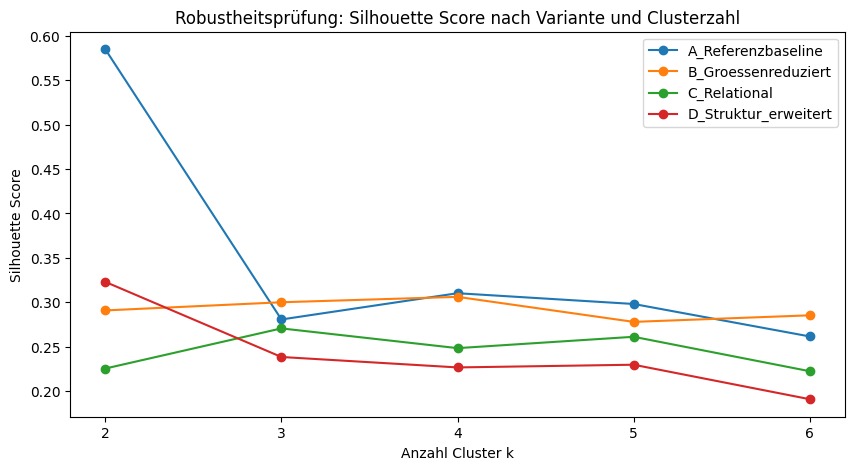

In [ ]:
# Silhouette Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["silhouette_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Silhouette Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

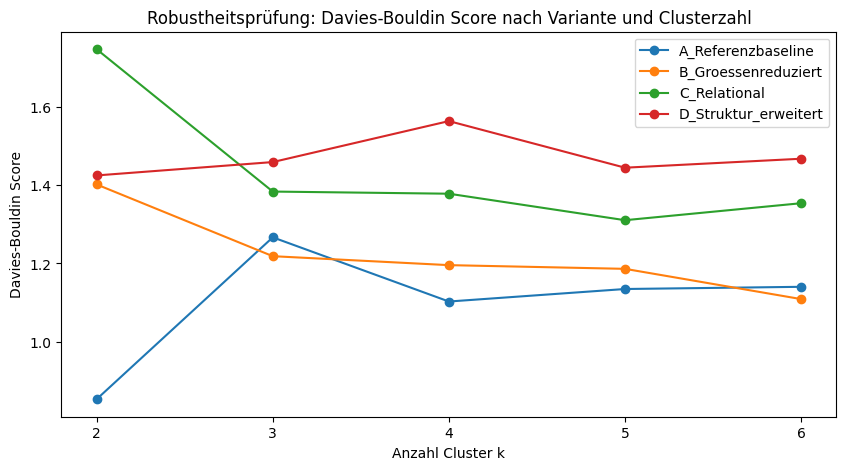

In [ ]:
# Davies-Bouldin Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["davies_bouldin_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Davies-Bouldin Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

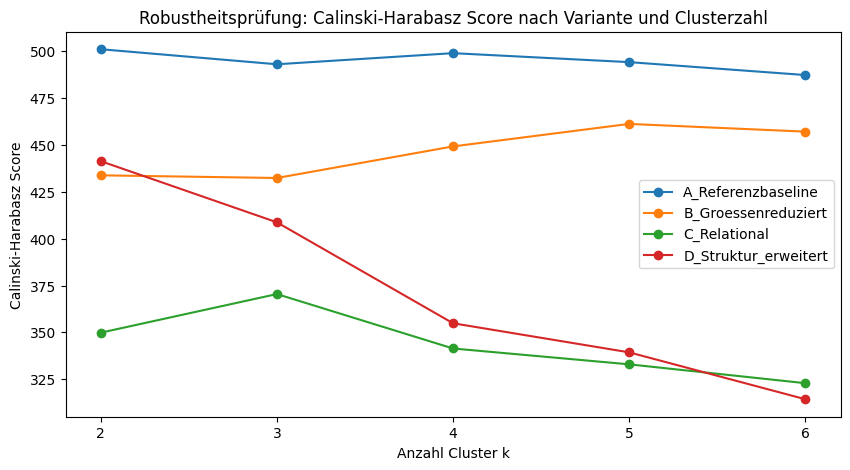

In [ ]:
# Calinski-Harabasz Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["calinski_harabasz_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Calinski-Harabasz Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

In [ ]:
# Für jede Variante die metrisch beste k=2- oder k=4-Lösung als Arbeitsbasis auswählen

robustness_selected_models = {}

for variant_name, prepared in robustness_prepared_data.items():
    variant_results = robustness_validation_df[
        (robustness_validation_df["variante"] == variant_name) &
        (robustness_validation_df["k"].isin([2, 4]))
    ].copy()

    if variant_results.empty:
        continue

    selected_row = variant_results.loc[variant_results["silhouette_score"].idxmax()]
    selected_k = int(selected_row["k"])

    X_variant_scaled = prepared["X_scaled"]
    feature_cols = prepared["feature_cols"]

    kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_variant_scaled)

    result_df = base_robustness_df.copy()
    cluster_col = f"cluster_{variant_name}"
    result_df[cluster_col] = labels

    cluster_sizes_df = (
        result_df[cluster_col]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    cluster_sizes_df.columns = ["cluster", "count"]

    cluster_profile_means_df = (
        result_df.groupby(cluster_col)[feature_cols]
        .mean()
        .round(3)
    )

    robustness_selected_models[variant_name] = {
        "selected_k": selected_k,
        "feature_cols": feature_cols,
        "cluster_col": cluster_col,
        "result_df": result_df,
        "cluster_sizes_df": cluster_sizes_df,
        "cluster_profile_means_df": cluster_profile_means_df
    }

print("Ausgewählte Vergleichsmodelle:")
for variant_name, model in robustness_selected_models.items():
    print(f"{variant_name}: k = {model['selected_k']}")

Ausgewählte Vergleichsmodelle:
A_Referenzbaseline: k = 2
B_Groessenreduziert: k = 4
C_Relational: k = 4
D_Struktur_erweitert: k = 2


In [ ]:
# Clustergrößen der ausgewählten Vergleichsmodelle zusammenführen

cluster_size_overview = []

for variant_name, model in robustness_selected_models.items():
    temp_df = model["cluster_sizes_df"].copy()
    temp_df["variante"] = variant_name
    temp_df["k"] = model["selected_k"]
    cluster_size_overview.append(temp_df)

robustness_cluster_sizes_overview_df = pd.concat(cluster_size_overview, ignore_index=True)
robustness_cluster_sizes_overview_df = robustness_cluster_sizes_overview_df[
    ["variante", "k", "cluster", "count"]
]

robustness_cluster_sizes_overview_df

,variante,k,cluster,count
0,A_Referenzbaseline,2,0,1293
1,A_Referenzbaseline,2,1,68
2,B_Groessenreduziert,4,0,197
3,B_Groessenreduziert,4,1,364
4,B_Groessenreduziert,4,2,213
5,B_Groessenreduziert,4,3,587
6,C_Relational,4,0,196
7,C_Relational,4,1,595
8,C_Relational,4,2,358
9,C_Relational,4,3,212


In [ ]:
# Clusterprofile je Variante ausgeben

for variant_name, model in robustness_selected_models.items():
    print("=" * 100)
    print(f"Variante: {variant_name}")
    print(f"Verwendete Clusterzahl: {model['selected_k']}")
    print(f"Features: {model['feature_cols']}")
    print()
    print("Clustergrößen:")
    display(model["cluster_sizes_df"])
    print()
    print("Mittlere Clusterprofile auf Originalskala:")
    display(model["cluster_profile_means_df"])
    print()

Variante: A_Referenzbaseline
Verwendete Clusterzahl: 2
Features: ['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

Clustergrößen:


,cluster,count
0,0,1293
1,1,68



Mittlere Clusterprofile auf Originalskala:


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_A_Referenzbaseline,,,,,,,,
0,7.626,2.084,2150.462,0.649,0.090,1.859,0.228,0.265
1,77.809,8.147,903.647,6.067,0.085,21.676,0.292,0.148



Variante: B_Groessenreduziert
Verwendete Clusterzahl: 4
Features: ['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate']

Clustergrößen:


...

,active_years_count,recency_days,net_per_invoice,invoices_per_active_year,net_per_active_year,placement_rate,leadership_rate
cluster_C_Relational,,,,,,,
0,1.883,2785.929,0.134,2.479,0.312,0.547,0.072
1,1.934,2928.156,0.063,2.882,0.177,0.142,0.019
2,1.953,859.704,0.109,3.024,0.313,0.180,0.797
3,4.854,1160.033,0.093,8.652,0.762,0.273,0.200



Variante: D_Struktur_erweitert
Verwendete Clusterzahl: 2
Features: ['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']

Clustergrößen:


,cluster,count
0,0,1082
1,1,279



Mittlere Clusterprofile auf Originalskala:


,active_years_count,recency_days,net_per_invoice,placement_rate,leadership_rate,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique
cluster_D_Struktur_erweitert,,,,,,,,,
0,1.671,2198.426,0.092,0.218,0.285,1.252,2.802,1.340,1.061
1,5.161,1660.570,0.083,0.281,0.162,2.943,5.875,2.986,1.602


In [ ]:
# Validierungs- und Robustheitsartefakte für das nächste Notebook speichern

validation_robustness_artifacts = {
    "debitor_features_final": debitor_features_final,
    "robustness_selected_models": robustness_selected_models,
    "robustness_validation_df": robustness_validation_df,
    "robustness_cluster_sizes_overview_df": robustness_cluster_sizes_overview_df
}

with open(ARTIFACT_DIR / "04_validation_robustness_artifacts.pkl", "wb") as f:
    pickle.dump(validation_robustness_artifacts, f)

print("Gespeichert:", ARTIFACT_DIR / "04_validation_robustness_artifacts.pkl")